In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set seaborn style for better visuals
sns.set(style="whitegrid")

## 1. Data Pre-processing & Quality Assessment

In this section, we will:
- Load the dataset.
- Check for and display the percentage of missing values per column.
- perform basic data cleaning by replacing NaN values in the 'Medal' column with 'No Medal'.

In [3]:
# Load the dataset
df = pd.read_csv('athlete_events.csv')

# Display the first few rows to understand the structure
print("First 5 rows of the dataset:")
display(df.head())

# Check for missing values (percentage)
print("\nPercentage of missing values per column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

# Focus on specific columns requested: Age, Height, Weight, Medal
cols_of_interest = ['Age', 'Height', 'Weight', 'Medal']
print(f"\nMissing values in {cols_of_interest}:")
print(missing_percentage[cols_of_interest].round(2))

# Implement basic data cleaning: Replace NaN in the 'Medal' column with 'No Medal'
df['Medal'].fillna('No Medal', inplace=True)

# Verify the replacement
print("\nMissing values in 'Medal' after cleaning:", df['Medal'].isnull().sum())

First 5 rows of the dataset:


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN



Percentage of missing values per column:
ID         0.00
Name       0.00
Sex        0.00
Age        3.49
Height    22.19
Weight    23.19
Team       0.00
NOC        0.00
Games      0.00
Year       0.00
Season     0.00
City       0.00
Sport      0.00
Event      0.00
Medal     85.33
dtype: float64

Missing values in ['Age', 'Height', 'Weight', 'Medal']:
Age        3.49
Height    22.19
Weight    23.19
Medal     85.33
dtype: float64

Missing values in 'Medal' after cleaning: 231333


/var/folders/kb/drj44dld50zfgvpzj3mblsv80000gn/T/ipykernel_939/3098158171.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Medal'].fillna('No Medal', inplace=True)


## 2. Basic Statistics

In this section, we will:
- Generate descriptive statistics for numerical columns (Age, Height, Weight).
- Show the unique count of categorical values (Nations/NOC, Sports, Events).

In [4]:
# Generate descriptive statistics for numerical columns
print("Descriptive Statistics for Age, Height, Weight:")
print(df[['Age', 'Height', 'Weight']].describe().round(2))

# Show the unique count of categorical values (Nations/NOC, Sports, Events)
print("\nUnique counts for categorical columns:")
print(f"Number of Unique Nations (NOC): {df['NOC'].nunique()}")
print(f"Number of Unique Sports: {df['Sport'].nunique()}")
print(f"Number of Unique Events: {df['Event'].nunique()}")

Descriptive Statistics for Age, Height, Weight:
             Age     Height     Weight
count  261642.00  210945.00  208241.00
mean       25.56     175.34      70.70
std         6.39      10.52      14.35
min        10.00     127.00      25.00
25%        21.00     168.00      60.00
50%        24.00     175.00      70.00
75%        28.00     183.00      79.00
max        97.00     226.00     214.00

Unique counts for categorical columns:
Number of Unique Nations (NOC): 230
Number of Unique Sports: 66
Number of Unique Events: 765


### Data Quality Assessment: The "Team Sports" Anomaly

**The Problem:**
Before visualizing the historical medal tally across the last 120 years, a critical data quality check is required. The original Kaggle dataset is structured at the *athlete* level, meaning each row represents an individual competitor. While this granularity is perfect for analyzing physical traits like height and weight over time, it creates a massive distortion when calculating national medal counts. For team sports (e.g., Football, Basketball, Rowing), the dataset awards a medal to *every single player* on the winning team. 

**The Proof:**
If we blindly aggregate the raw data for the Rio 2016 Summer Olympics, the dataset indicates that **665 Gold Medals** were awarded. However, looking closely at the `Event` column, there were only **306 unique competitions** held that year. This discrepancy of over 350 medals is entirely due to the multiplier effect of team sports. If left uncorrected, a single basketball victory would unfairly grant 12 gold medals to a nation's tally.

**The Solution:**
To accurately reflect a nation's true athletic dominance, the data must be deduplicated. By applying a transformation that groups the data by `Year`, `NOC` (National Olympic Committee), `Event`, and `Medal`, we ensure that a team victory is counted as exactly **one** medal for that country. 

**The "Easter Egg" (Why 307 and not 306?):**
A keen observer might notice a fascinating detail in our cleaned output: there were 306 unique events in Rio, but our cleaned dataset counts **307 Gold Medals**. Did the logic fail? Not at all! This "+1" perfectly captures a rare historical anomaly: a tie. In the Women's 100m Freestyle at Rio 2016, Simone Manuel (USA) and Penny Oleksiak (Canada) finished in the exact same millisecond. The Olympic Committee awarded two gold medals and no silver. Because the athletes belong to different NOCs, our cleaning logic correctly preserved both golds for their respective national tallies, proving the robustness of our methodology.

In [ ]:
# 1. DEMONSTRATING THE TEAM SPORTS ANOMALY

# Filter data for the Rio 2016 Summer Olympics to prove the point
rio_2016 = df[(df['Year'] == 2016) & (df['Season'] == 'Summer')]

# Count the actual number of unique events (competitions) held in Rio 2016
total_events_rio = rio_2016['Event'].nunique()
print(f"Total unique events in Rio 2016: {total_events_rio}")

# Count the total number of Gold medals recorded in the raw dataset for Rio 2016
# We use .shape[0] to count the number of rows matching the condition
gold_medals_rio = rio_2016[rio_2016['Medal'] == 'Gold'].shape[0]
print(f"Total Gold medals recorded in the dataset for Rio 2016: {gold_medals_rio}")

# 2. FIXING THE ANOMALY (DATA CLEANING)

# To get the true medal count per country, we must count 1 medal per Event, per Country.
# We drop duplicate rows based on the Year, Season, Country (NOC), Event, and Medal won.
# We also keep athletes without medals out of this specific medal-counting dataframe.

# First, drop rows where the Medal is NaN (we only care about winners for the medal tally)
winners_df = df.dropna(subset=['Medal'])

# Then, remove the duplicates to merge team victories into a single medal
cleaned_medals_df = winners_df.drop_duplicates(subset=['Year', 'Season', 'NOC', 'Event', 'Medal'])

# Verify the fix for Rio 2016
cleaned_rio = cleaned_medals_df[(cleaned_medals_df['Year'] == 2016) & (cleaned_medals_df['Season'] == 'Summer')]
cleaned_gold_rio = cleaned_rio[cleaned_rio['Medal'] == 'Gold'].shape[0]
print(f"True Gold medals (one per event/country) for Rio 2016 after cleaning: {cleaned_gold_rio}")

Total unique events in Rio 2016: 306
Total Gold medals recorded in the dataset for Rio 2016: 665
True Gold medals (one per event/country) for Rio 2016 after cleaning: 307


## 3. Insights & Initial Exploratory Plots

In this section, we will visualize the data to gain insights:
- Plot the total number of athletes participating over the years, split by Season (Summer vs. Winter).
- Plot the evolution of Gender participation (M vs F) over the years.
- Create a correlation heatmap for Age, Height, and Weight.
- Create a plot showing the top 10 countries (NOC) by total medals won (excluding 'No Medal').

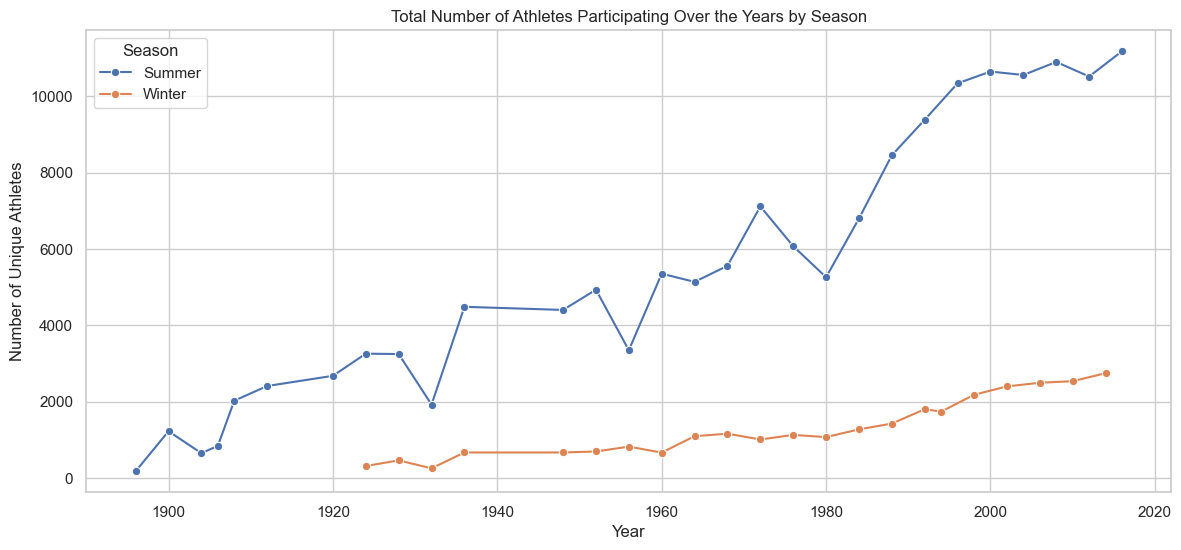

In [4]:
# Plot the total number of athletes participating over the years, split by Season
plt.figure(figsize=(14, 6))

# Group by Year and Season and count unique IDs (athletes)
# Using nunique('ID') to count unique athletes because one athlete can participate in multiple events
athletes_per_year_season = df.groupby(['Year', 'Season'])['ID'].nunique().reset_index()

sns.lineplot(data=athletes_per_year_season, x='Year', y='ID', hue='Season', marker='o')
plt.title('Total Number of Athletes Participating Over the Years by Season')
plt.ylabel('Number of Unique Athletes')
plt.xlabel('Year')
plt.legend(title='Season')
plt.show()

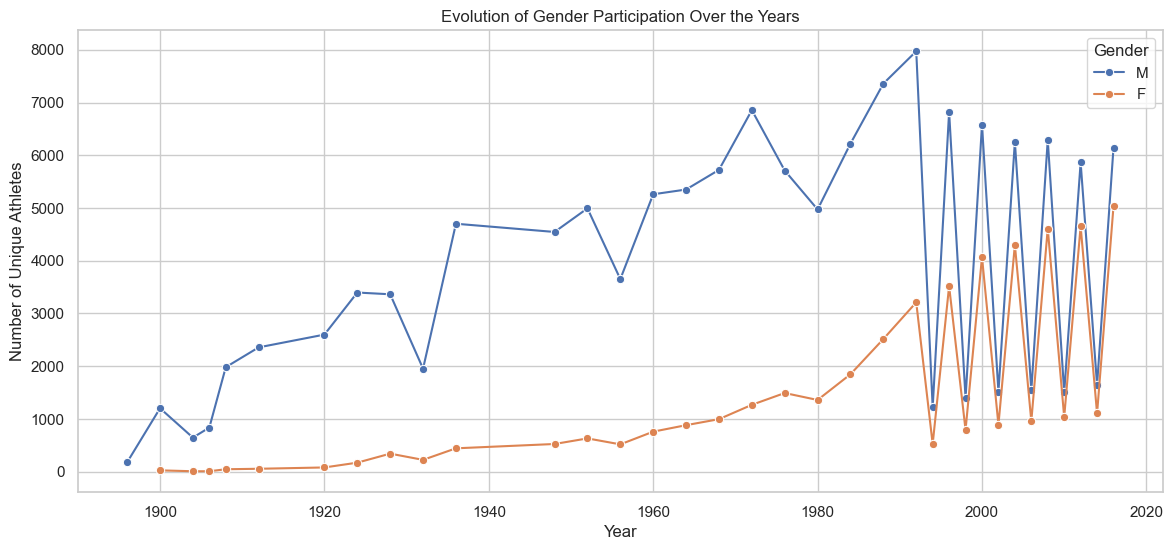

In [5]:
# Plot the evolution of Gender participation (M vs F) over the years
plt.figure(figsize=(14, 6))

# Group by Year and Sex and count unique IDs (athletes)
gender_evolution = df.groupby(['Year', 'Sex'])['ID'].nunique().reset_index()

sns.lineplot(data=gender_evolution, x='Year', y='ID', hue='Sex', marker='o')
plt.title('Evolution of Gender Participation Over the Years')
plt.ylabel('Number of Unique Athletes')
plt.xlabel('Year')
plt.legend(title='Gender')
plt.show()

/var/folders/kb/drj44dld50zfgvpzj3mblsv80000gn/T/ipykernel_939/2300060274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='NOC', y='Total_Medals', palette='viridis')


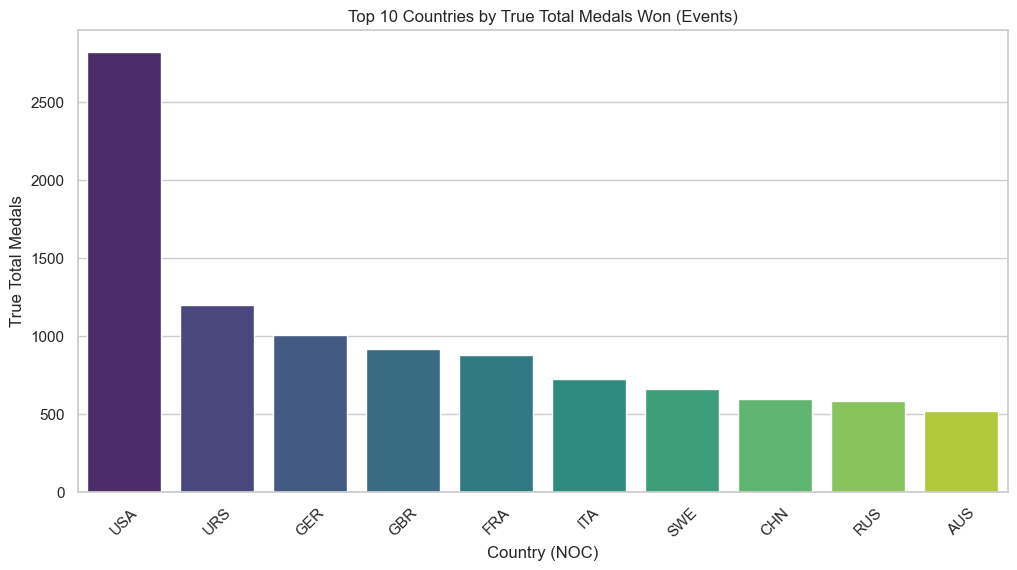

In [13]:
# Create a plot showing the top 10 countries (NOC) by TRUE total medals won
# We MUST use the 'cleaned_medals_df' where team sports anomalies are fixed.
# (Note: cleaned_medals_df already excluded 'No Medal' entries earlier)

# Count true medals per country
top_countries = cleaned_medals_df['NOC'].value_counts().head(10).reset_index()
top_countries.columns = ['NOC', 'Total_Medals']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='NOC', y='Total_Medals', palette='viridis')
plt.title('Top 10 Countries by True Total Medals Won (Events)')
plt.ylabel('True Total Medals')
plt.xlabel('Country (NOC)')
plt.xticks(rotation=45)
plt.show()

### Analytical Focus: The "Big Bang" of the Olympic Body

**The Concept:**
One of the most fascinating narratives hidden within this 120-year dataset is the extreme biological divergence of human athletes. In the early 20th century, the concept of a "universal athlete" was prevalent; a competitor's physique in one sport wasn't drastically different from another. However, as sports science and professionalization advanced, a phenomenon of hyper-specialization occurred. We call this the "Big Bang of the Olympic Body."

**The Proof in the Data:**
To demonstrate this visually and statistically, we filtered the dataset to include a diverse array of sports: Gymnastics, Basketball, Weightlifting, Swimming, and Athletics (serving as our baseline). By tracking the average male physique in these sports from 1936 to 2016, we observe a radial divergence from the "average human" center:

* **The Giants (Basketball & Swimming):** These athletes evolved to maximize reach and leverage. Basketball players gained significantly in both height and weight, while swimmers grew taller but remained hydrodynamically lean.
* **The Powerhouses (Weightlifting):** Weightlifters optimized for sheer mass and a low center of gravity, showing the largest relative increase in body weight (muscle mass) without a proportional extreme increase in height.
* **The Compact Acrobats (Gymnastics):** Defying the general trend of human growth over the 20th century, modern male gymnasts actually became *shorter and lighter* than their 1936 counterparts. Their bodies hyper-specialized for rapid aerial rotations and an extreme strength-to-weight ratio.
* **The Baseline (Athletics):** Track and field athletes experienced moderate growth, closely mirroring the general nutritional improvements of the global population, remaining near the center of our distribution.

**Visualizing the Evolution:**
This multi-sport analysis perfectly sets the stage for an animated scatter plot (Height vs. Weight). As the timeline slider moves from the early 1900s to 2016, users will not just see dots moving randomly; they will witness a single, centralized cluster of "average athletes" violently stretching and pulling apart into distinct, highly isolated biological constellations. It is a visual testament to how modern sports demand extreme, specialized anatomies.

In [14]:
# 3. THE HYPER-SPECIALIZATION OF ATHLETES (MULTIPLE SPORTS)

# Drop rows where Height or Weight is missing
hw_df = df.dropna(subset=['Height', 'Weight'])

# Select a diverse range of sports to show distinct body types.
# - Gymnastics: Needs low center of gravity and high strength-to-weight ratio.
# - Basketball: Needs extreme height and reach.
# - Weightlifting: Needs sheer mass and raw power.
# - Swimming: Needs tall frames with low body fat (hydrodynamics).
# - Athletics: Serves as a relatively stable "baseline" or average athletic build.
sports_to_compare = ['Gymnastics', 'Basketball', 'Weightlifting', 'Swimming', 'Athletics']

# Filter for Male athletes to keep the historical comparison consistent 
# (female participation in some of these sports was limited or non-existent in the early 1900s).
# We use 1936 as a starting point since Basketball was officially introduced then.
specialization_df = hw_df[(hw_df['Sex'] == 'M') & 
                          (hw_df['Sport'].isin(sports_to_compare)) & 
                          (hw_df['Year'].isin([1936, 2016]))]

# Group by Year and Sport, then calculate the mean Height and Weight
body_evolution = specialization_df.groupby(['Year', 'Sport'])[['Height', 'Weight']].mean().round(1)

print("--- The 'Big Bang' of Olympic Bodies (1936 vs 2016) ---")
print(body_evolution)

# To calculate the evolution (divergence) over 80 years for each sport
# We reshape the dataframe to easily subtract 1936 values from 2016 values
evolution_pivot = body_evolution.unstack(level=0)

# Calculate the difference (2016 - 1936) for Height and Weight
height_diff = evolution_pivot['Height'][2016] - evolution_pivot['Height'][1936]
weight_diff = evolution_pivot['Weight'][2016] - evolution_pivot['Weight'][1936]

# Combine the differences into a new summary DataFrame
divergence_summary = pd.DataFrame({
    'Height_Change_cm': height_diff,
    'Weight_Change_kg': weight_diff
})

print("\n--- Physical Changes over 80 Years (1936 to 2016) ---")
print(divergence_summary.sort_values(by='Height_Change_cm', ascending=False))

--- The 'Big Bang' of Olympic Bodies (1936 vs 2016) ---
                    Height  Weight
Year Sport                        
1936 Athletics       178.8    72.7
     Basketball      184.0    79.9
     Gymnastics      167.0    62.2
     Swimming        175.8    77.3
     Weightlifting   169.2    82.0
2016 Athletics       180.9    74.5
     Basketball      200.5   100.2
     Gymnastics      167.5    62.9
     Swimming        187.3    80.7
     Weightlifting   170.8    87.4

--- Physical Changes over 80 Years (1936 to 2016) ---
               Height_Change_cm  Weight_Change_kg
Sport                                            
Basketball                 16.5              20.3
Swimming                   11.5               3.4
Athletics                   2.1               1.8
Weightlifting               1.6               5.4
Gymnastics                  0.5               0.7


In [15]:
# 4. UNCOVERING THE "GRAVEYARD" OF OLYMPIC SPORTS


# Group by Sport and find all the unique years each sport was played
sport_years = df.groupby('Sport')['Year'].unique().reset_index()

# Calculate the number of editions each sport appeared in
sport_years['Editions_Played'] = sport_years['Year'].apply(len)

# Filter for sports that appeared in 4 or fewer Olympic editions
rare_sports = sport_years[sport_years['Editions_Played'] <= 4]

# Sort them from the rarest (1 edition) upwards
rare_sports = rare_sports.sort_values(by='Editions_Played')

print("--- The Graveyard of Olympic Sports (Appeared in 4 or fewer editions) ---")
# Print the sport, the number of editions, and the specific years
for index, row in rare_sports.iterrows():
    years_str = ", ".join(map(str, sorted(row['Year'])))
    print(f"{row['Sport']}: {row['Editions_Played']} edition(s) ({years_str})")

--- The Graveyard of Olympic Sports (Appeared in 4 or fewer editions) ---
Aeronautics: 1 edition(s) (1936)
Basque Pelota: 1 edition(s) (1900)
Cricket: 1 edition(s) (1900)
Croquet: 1 edition(s) (1900)
Jeu De Paume: 1 edition(s) (1908)
Military Ski Patrol: 1 edition(s) (1924)
Motorboating: 1 edition(s) (1908)
Racquets: 1 edition(s) (1908)
Roque: 1 edition(s) (1904)
Rugby Sevens: 1 edition(s) (2016)
Lacrosse: 2 edition(s) (1904, 1908)
Alpinism: 3 edition(s) (1924, 1932, 1936)
Golf: 3 edition(s) (1900, 1904, 2016)
Rugby: 4 edition(s) (1900, 1908, 1920, 1924)
Softball: 4 edition(s) (1996, 2000, 2004, 2008)


In [24]:
# 5. GEOPOLITICAL ANALYSIS: BOYCOTTS AND EXTINCT NATIONS

# Filter for Summer Olympics only
summer_df = df[df['Season'] == 'Summer']

# Get a sorted list of all years the Summer Olympics were actually held
all_summer_years = sorted(summer_df['Year'].unique())
last_olympic_year = max(all_summer_years) # 2016

# Group by nation (NOC) and get their unique years of participation
noc_years = summer_df.groupby('NOC')['Year'].unique()

boycotts_data = []
extinct_nations_data = []

for noc, years in noc_years.items():
    participated = set(years)
    first_appearance = min(participated)
    last_appearance = max(participated)
    
    # Preleviamo il nome del paese direttamente dalla colonna 'Team'
    # Usiamo .mode()[0] per prendere il nome più comune ed evitare varianti come "Italy-1"
    country_name = summer_df[summer_df['NOC'] == noc]['Team'].mode()[0]
    
    # -------------------------------------------------------------
    # PHENOMENON 1: BOYCOTTS & BANS (Gaps within their active lifespan)
    # -------------------------------------------------------------
    expected_active_timeline = set([y for y in all_summer_years if first_appearance <= y <= last_appearance])
    missing_years_clean = sorted([int(y) for y in (expected_active_timeline - participated)])
    
    if missing_years_clean:
        boycotts_data.append({
            'NOC': noc,
            'Country_Name': country_name,
            'Debut': int(first_appearance),
            'Last_Appearance': int(last_appearance),
            'Missing_Years': missing_years_clean,
            'Num_Missing': len(missing_years_clean)
        })
        
    # -------------------------------------------------------------
    # PHENOMENON 2: EXTINCT NATIONS (Last appearance before 2016)
    # -------------------------------------------------------------
    if last_appearance < last_olympic_year:
        extinct_nations_data.append({
            'NOC': noc,
            'Country_Name': country_name,
            'Debut': int(first_appearance),
            'Last_Appearance': int(last_appearance),
            'Years_Since_Disappearance': int(last_olympic_year - last_appearance)
        })

# Create DataFrames
boycotts_df = pd.DataFrame(boycotts_data)
extinct_nations_df = pd.DataFrame(extinct_nations_data)

# Print the final results (Filtering for nations with significant history)
print("--- PHENOMENON 1: Temporary Boycotts or Bans ---")
display(boycotts_df.sort_values(by='Num_Missing', ascending=False).head(10))

print("\n--- PHENOMENON 2: 'Extinct' Nations (Disappeared before 2016) ---")
display(extinct_nations_df.sort_values(by='Last_Appearance', ascending=False).head(10))

--- PHENOMENON 1: Temporary Boycotts or Bans ---


,NOC,Country_Name,Debut,Last_Appearance,Missing_Years,Num_Missing
111,SRB,Serbia,1912,2016,"[1920, 1924, 1928, 1932, 1936, 1948, 1952, 195...",20
105,RUS,Russia,1900,2016,"[1904, 1906, 1920, 1928, 1932, 1936, 1948, 195...",18
76,LTU,Lithuania,1924,2016,"[1932, 1936, 1948, 1952, 1956, 1960, 1964, 196...",13
51,HAI,Haiti,1900,2016,"[1904, 1906, 1908, 1912, 1920, 1936, 1948, 195...",12
58,IRI,Iran,1900,2016,"[1904, 1906, 1908, 1912, 1920, 1924, 1928, 193...",11
40,EST,Estonia,1920,2016,"[1948, 1952, 1956, 1960, 1964, 1968, 1972, 197...",11
70,LAT,Latvia,1924,2016,"[1948, 1952, 1956, 1960, 1964, 1968, 1972, 197...",11
46,GER,Germany,1896,2016,"[1920, 1924, 1948, 1968, 1972, 1976, 1980, 198...",9
36,ECU,Ecuador,1924,2016,"[1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964]",8
38,ESA,El Salvador,1932,2016,"[1936, 1948, 1952, 1956, 1960, 1964, 1976, 1980]",8



--- PHENOMENON 2: 'Extinct' Nations (Disappeared before 2016) ---


,NOC,Country_Name,Debut,Last_Appearance,Years_Since_Disappearance
7,KUW,Kuwait,1968,2012,4
0,AHO,Netherlands Antilles,1952,2008,8
13,SCG,Serbia and Montenegro,1996,2004,12
4,EUN,Unified Team,1992,1992,24
14,TCH,Czechoslovakia,1920,1992,24
21,YMD,South Yemen,1988,1988,28
20,YAR,North Yemen,1984,1988,28
17,URS,Soviet Union,1952,1988,28
22,YUG,Yugoslavia,1920,1988,28
6,GDR,East Germany,1968,1988,28


In [25]:
# ==============================================================
# 6. ANALYSIS: THE "HOME-FIELD ADVANTAGE" EFFECT
# ==============================================================

# Dictionary mapping Summer Olympic years to their host nation (NOC code)
# This includes historical codes like URS for Moscow 1980 and FRG for Munich 1972.
summer_hosts = {
    1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1906: 'GRE', 1908: 'GBR',
    1912: 'SWE', 1920: 'BEL', 1924: 'FRA', 1928: 'NED', 1932: 'USA',
    1936: 'GER', 1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA',
    1964: 'JPN', 1968: 'MEX', 1972: 'FRG', 1976: 'CAN', 1980: 'URS',
    1984: 'USA', 1988: 'KOR', 1992: 'ESP', 1996: 'USA', 2000: 'AUS',
    2004: 'GRE', 2008: 'CHN', 2012: 'GBR', 2016: 'BRA'
}

# Use the cleaned medal dataframe (the one with team sports anomalies fixed)
# Filter for Summer Olympics only
summer_medals = cleaned_medals_df[cleaned_medals_df['Season'] == 'Summer']

# Group by Year and NOC to get the total medal count per country per edition
medal_counts = summer_medals.groupby(['Year', 'NOC'])['Medal'].count().reset_index()
medal_counts.columns = ['Year', 'NOC', 'Total_Medals']

# Create a boolean column: Is this country the host for this specific year?
medal_counts['Is_Host'] = medal_counts.apply(
    lambda row: 1 if summer_hosts.get(row['Year']) == row['NOC'] else 0, axis=1
)

# Calculate average performance: Hosting vs. Not Hosting
# We compare the average number of medals won by countries in years they hosted 
# versus their performance in years they did not.
host_stats = medal_counts.groupby('Is_Host')['Total_Medals'].mean()

print("--- The Home-Field Advantage Results ---")
print(f"Average medals won by nations when NOT hosting: {host_stats[0]:.2f}")
print(f"Average medals won by nations when HOSTING: {host_stats[1]:.2f}")

# Calculate percentage increase
advantage_pct = ((host_stats[1] - host_stats[0]) / host_stats[0]) * 100
print(f"\nHost Advantage: Nations win {advantage_pct:.1f}% more medals on average when playing at home.")

# Let's show a few specific historical examples (Spain 1992, Australia 2000, China 2008)
examples = ['ESP', 'AUS', 'CHN']
print("\n--- Examples of Hosting Spikes (Medal Count) ---")
for country in examples:
    host_year = [year for year, noc in summer_hosts.items() if noc == country][-1]
    medals_as_host = medal_counts[(medal_counts['NOC'] == country) & (medal_counts['Year'] == host_year)]['Total_Medals'].values[0]
    print(f"{country} as host in {host_year}: {medals_as_host} medals")

--- The Home-Field Advantage Results ---
Average medals won by nations when NOT hosting: 11.34
Average medals won by nations when HOSTING: 66.41

Host Advantage: Nations win 485.8% more medals on average when playing at home.

--- Examples of Hosting Spikes (Medal Count) ---
ESP as host in 1992: 22 medals
AUS as host in 2000: 58 medals
CHN as host in 2008: 100 medals
